# Customer Analysis 

## Objective 

The objective of this notebook is to analyze customer purchasing behavior and identify valuable customer segments using the RFM model.

The RFM model evaluate customers based on: 

- Recency
- Frequency
- Monetary Value 

The insight will support customer retention and marketing strategies.

In [71]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
# Load Cleaned Dataset
df=pd.read_csv("../data/processed/online_retail_clean.csv")

In [73]:
# Converting InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [74]:
sales_df = df[
    (df["Quantity"]>0) &
    (df["Price"]>0)
].copy()

sales_df["Sales"] =(
sales_df["Quantity"] * 
sales_df["Price"]
)

In [75]:
sales_df.info()
sales_df.head()

<class 'pandas.DataFrame'>
Index: 1007914 entries, 0 to 1028000
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007914 non-null  str           
 1   StockCode    1007914 non-null  str           
 2   Description  1007914 non-null  str           
 3   Quantity     1007914 non-null  int64         
 4   InvoiceDate  1007914 non-null  datetime64[us]
 5   Price        1007914 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007914 non-null  str           
 8   Sales        1007914 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 76.9 MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [76]:
# Set Reference Date

reference_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [77]:
# Aggregating sales by customer ID

rfm = sales_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})

In [78]:
rfm.head()

,InvoiceDate,Invoice,Sales
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [79]:
rfm.columns = [
    "Customer ID",
    "Recency",
    "Frequency",
    "Monetary"
]

ValueError: Length mismatch: Expected axis has 3 elements, new values have 4 elements

In [ ]:
rfm = rfm.reset_index()

In [ ]:
rfm.columns = [
    "Customer ID",
    "Recency",
    "Frequency",
    "Monetary"
]

In [ ]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [ ]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5878 non-null   float64
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [ ]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


### Interpretation

- The dataset contains 5,878 unique customers with complete RFM information.
- The median Recency is 96 days, while 25% of customers have not purchased for more than 380 days, indicating a substantial inactive customer segment.
- Frequency is highly skewed, with 25% of customers making only one purchase, while a few customers purchased hundreds of times.
- These finding support the use of RFM scoring to identify valuable customers and prioritize retention or reactivation strategies.

In [ ]:
# Creating R (Recency) Score

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5, 
    labels = [5, 4, 3, 2, 1]
)

In [ ]:
# Checking R Score on the RFM table

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score
0,12346.0,326,12,77556.46,2
1,12347.0,2,8,4921.53,5
2,12348.0,75,5,2019.40,3
3,12349.0,19,4,4428.69,5
4,12350.0,310,1,334.40,2


In [ ]:
# Creating F Score on the RFM table
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

ValueError: Bin edges must be unique: Index([1.0, 1.0, 2.0, 4.0, 8.0, 398.0], dtype='float64', name='Frequency').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
# Recreating F score to avoide too many duplicates

rfm["F_Score"]=pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels= [1, 2, 3, 4, 5]
)


In [ ]:
# Checking F Score
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score
0,12346.0,326,12,77556.46,2,5
1,12347.0,2,8,4921.53,5,4
2,12348.0,75,5,2019.40,3,4
3,12349.0,19,4,4428.69,5,3
4,12350.0,310,1,334.40,2,1


## Frequecy Scoring Method

Frequency contains many duplicate values (especially one time purchasers). To ensure stable quantitle-based scoring, ranking was applied before using 'pd.qcut()'.

In [ ]:
# Creating Monetary Score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,12,77556.46,2,5,5
1,12347.0,2,8,4921.53,5,4,5
2,12348.0,75,5,2019.40,3,4,4
3,12349.0,19,4,4428.69,5,3,5
4,12350.0,310,1,334.40,2,1,2


In [ ]:
# Coversion of data type (RFM Score to 'str')

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [ ]:
# Creating RF Score

rfm["RF_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
) 

In [ ]:
# Checking RF Score
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RF_Score
0,12346.0,326,12,77556.46,2,5,5,255,25
1,12347.0,2,8,4921.53,5,4,5,545,54
2,12348.0,75,5,2019.40,3,4,4,344,34
3,12349.0,19,4,4428.69,5,3,5,535,53
4,12350.0,310,1,334.40,2,1,2,212,21


In [ ]:
#  Custoemr Segmentation based on RF Score

def segment_customer(rf_score): 

    if rf_score == "55" :
        return "Champion"

    elif rf_score in ["54", "45", "44"]:
        return "Loyal Customer"

    elif rf_score in ["53", "52", "43", "42"]:
        return "Potential Loyalist"

    elif rf_score in ["35", "34", "33"]:
        return "Need Attention"

    elif rf_score in ["25", "24", "23"]:
        return "At Risk"

    elif rf_score in ["15", "14", "13", "12", "11"]:
        return "Lost Customer"

    else:
        return "Others"

In [ ]:
# Creating Segment Columns

rfm["Segment"] = rfm["RF_Score"].apply(segment_customer)

In [ ]:
# Checking Customer Segment Column on RFM Table
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RF_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,255,25,At Risk
1,12347.0,2,8,4921.53,5,4,5,545,54,Loyal Customer
2,12348.0,75,5,2019.40,3,4,4,344,34,Need Attention
3,12349.0,19,4,4428.69,5,3,5,535,53,Potential Loyalist
4,12350.0,310,1,334.40,2,1,2,212,21,Others


In [ ]:
# Counting No of customer by segment

segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customer Count"]

segment_summary

,Segment,Customer Count
0,Lost Customer,1175
1,Others,1174
2,Loyal Customer,911
3,Need Attention,782
4,Potential Loyalist,714
5,Champion,571
6,At Risk,551


In [ ]:
# Number and proportion of customer by segment 

segment_summary["Percentage"] = (
    segment_summary["Customer Count"]
    / segment_summary["Customer Count"].sum()
    *100
).round(1)

segment_summary

,Segment,Customer Count,Percentage
0,Lost Customer,1175,20.0
1,Others,1174,20.0
2,Loyal Customer,911,15.5
3,Need Attention,782,13.3
4,Potential Loyalist,714,12.1
5,Champion,571,9.7
6,At Risk,551,9.4


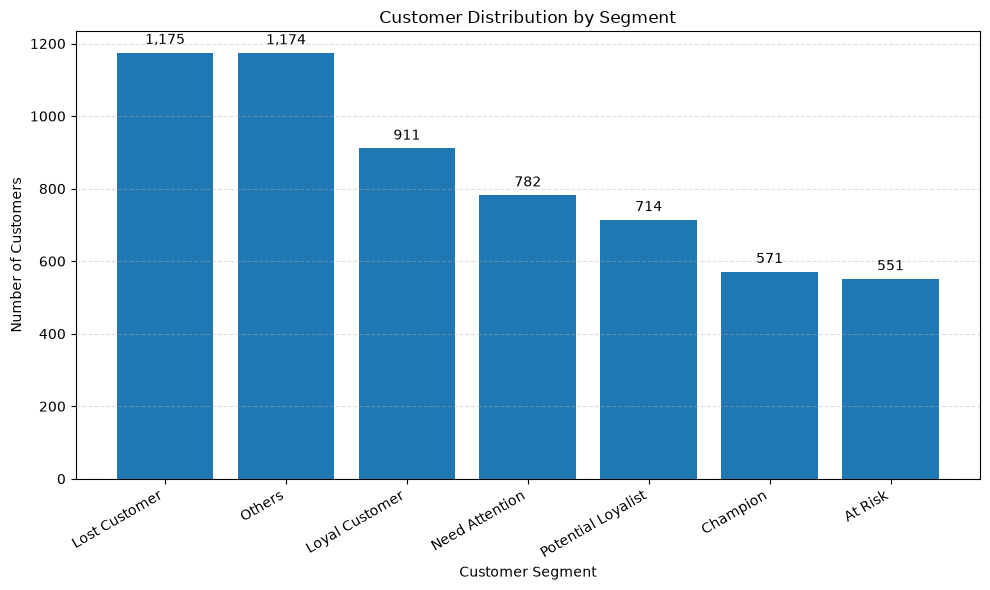

In [ ]:
# Creating Bar Chart to make comparision between segments

plt.figure(figsize=(10,6))

bars= plt.bar(
    segment_summary["Segment"],
    segment_summary["Customer Count"]
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar in bars: 
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height +15, 
        f"{int(height):,}",
        ha= "center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Revenue by custoemr segment 

sales_segment = sales_df.merge(
    rfm[["Customer ID", "Segment"]],
    on = "Customer ID",
    how="left"
)

sales_segment.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Segment
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Need Attention
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Need Attention
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Need Attention
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Need Attention
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Need Attention


In [ ]:
# Total sales revenue by segments

segment_revenue = (
    sales_segment
    .groupby("Segment", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

segment_revenue

,Segment,Sales
1,Champion,8364230.024
3,Loyal Customer,3660100.121
4,Need Attention,2030727.705
0,At Risk,1129337.081
2,Lost Customer,848032.653
6,Potential Loyalist,815892.041
5,Others,526484.643


In [ ]:
# Total sales revenue and proportion by segement 

segment_revenue["Revenue %"] = (
    segment_revenue["Sales"]
    / segment_revenue["Sales"].sum()
    * 100
).round(1)

segment_revenue

,Segment,Sales,Revenue %
1,Champion,8364230.024,48.1
3,Loyal Customer,3660100.121,21.1
4,Need Attention,2030727.705,11.7
0,At Risk,1129337.081,6.5
2,Lost Customer,848032.653,4.9
6,Potential Loyalist,815892.041,4.7
5,Others,526484.643,3.0


### Business Insight

- Champion customers represent only  **9.7%** of the customer base but generate **48.1%**of total revenue.
- Champion and Loyal customers together contribute approximately **69.2%** of total sales, highlighting the importance of retaining high-value customers.
- Need Attention customers still account for **11.7%** of revenue, suggesting an opportunity for proactive retention campaigns.
- The analysis confirms that customer value is highly concentrated among a relatively small group of customers, consistent with the Pareto Principle.

In [ ]:
# Join two table (Revenye table + Customer Count Table) 

segment_value = segment_revenue.merge(
    segment_summary,
    on="Segment"
)

segment_value

,Segment,Sales,Revenue %,Customer Count,Percentage
0,Champion,8364230.024,48.1,571,9.7
1,Loyal Customer,3660100.121,21.1,911,15.5
2,Need Attention,2030727.705,11.7,782,13.3
3,At Risk,1129337.081,6.5,551,9.4
4,Lost Customer,848032.653,4.9,1175,20.0
5,Potential Loyalist,815892.041,4.7,714,12.1
6,Others,526484.643,3.0,1174,20.0


In [ ]:
# Average Revenue per Customer (Proxy for Customer Lifetime Value)

segment_value["Avg Revenue per Customer"] = (
    segment_value["Sales"]
    /segment_value["Customer Count"]
).round(2)

segment_value

,Segment,Sales,Revenue %,Customer Count,Percentage,Avg Revenue per Customer
0,Champion,8364230.024,48.1,571,9.7,14648.39
1,Loyal Customer,3660100.121,21.1,911,15.5,4017.67
2,Need Attention,2030727.705,11.7,782,13.3,2596.84
3,At Risk,1129337.081,6.5,551,9.4,2049.61
4,Lost Customer,848032.653,4.9,1175,20.0,721.73
5,Potential Loyalist,815892.041,4.7,714,12.1,1142.71
6,Others,526484.643,3.0,1174,20.0,448.45


### Business Insight

- Champion customers generated the highest average revenue per customer (£14,648), making them the most valuable customer segment.
- Although Loyal Customers accounted for a larger customer base, their average customer value was significantly lower than that of Champions. 
- Need Attention customers still showed relatively high customer value, indicating strong potential for targeted retention campaigns.
- Lost Customers represented a large proportion of the customer base but generated relatively low average revenue per customer, suggesting that seletive reactivation strategies may be more cost-effective than braod campaigns.

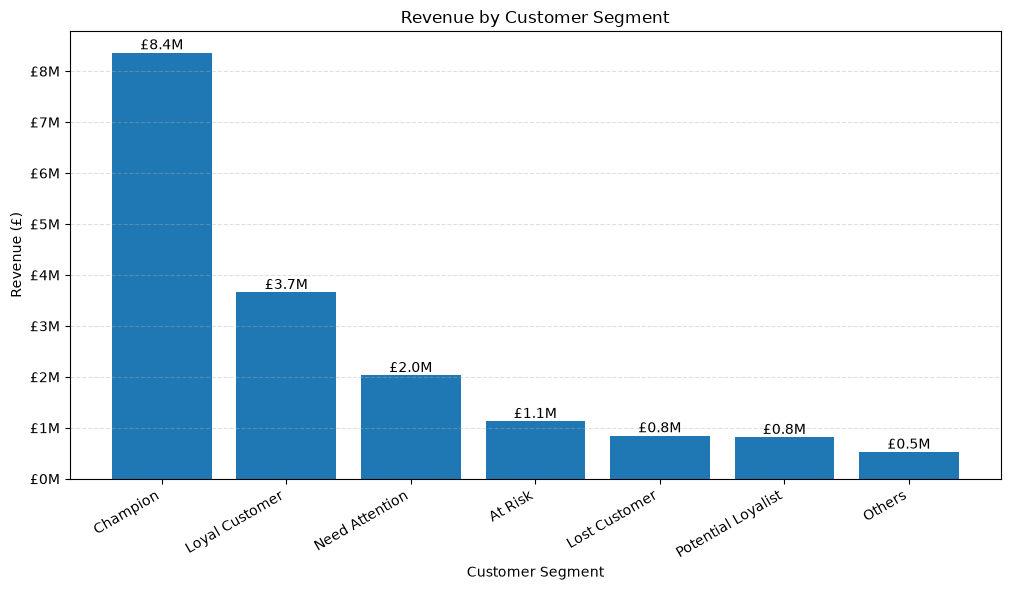

In [ ]:
# Revenue by segment chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Sales"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"£{height / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/ 1_000_000:.0f}M")
)

plt.show()


### Interpretation

- Champion customers generated approximately £8.4 million, accounting for the highest revenue among all segments.
- Loyal Customers contributed the second-largest revenue at approximately £3.7million.
- Champion and Loyal Customers together generated about 69% of total revenue.
- Need Attention and At Risk customers also contributed meaningful revenue, indicating opportunities for targeted retention campaigns.

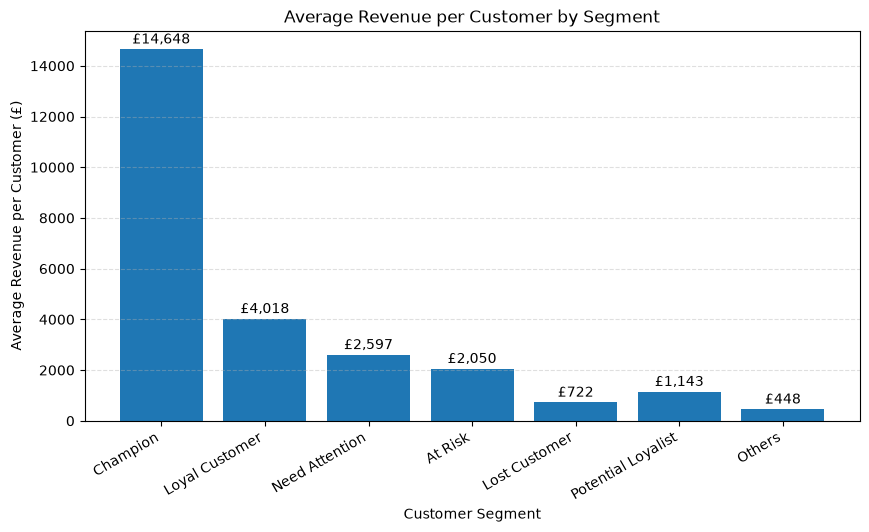

In [83]:
## Average sales revenue per customers by segment

plt.figure (figsize=(10,6))

bars = plt.bar(
    segment_value["Segment"],
    segment_value["Avg Revenue per Customer"]
)

plt.title("Average Revenue per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue per Customer (£)")

plt.xticks(rotation=30, ha= "right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height +100,
        f"£{height:,.0f}",
        ha= "center",
        va= "bottom"
    )
plt.subplots_adjust(
    bottom=0.25,
    top=0.90
)
plt.show()

### Interpretation
- Champion customers generated the highest average revenue per customer at approximately £14,648.
- Their average value was about 3.6 times higher than that of Loyal Customers.
- Need Attention and At Risk Customers still showed meaningful customer value, supporting targeting retention strategeis.
- Lost Customers and Others had much lower average revenue per customer, suggesting that broad reactivation campaigns may be less cost-effective.


# Customer Analysis Summary

This analysis used the RFM (Recency, Frequency, Monetary) model to segment customers based on purchasing behavior and evaluate customer value.

Key findings include: 

- Champion customers represented only 9.7% of all customers but generated 48.1% of total revenue.
- Champion and Loyal Customers together contributed approximately 69% of total sales. 
- Need Attention and At Risk customers still generated meaningful revenue, indicating opportunities for targeted retention strategies.
- Lost Customers accounted for 20% of the customer base but generated relatively low average revenue per customer.
- The analysis confirmed that customer value is highly concentrated among a relatively small group of customers, supporting the Pareto Principle. 

Overall, the findings demonstrate how customer segmentation can support data-driven business decisions by identifying high-value customers, prioritizing retention efforts, and optimizing marketing investments. This result provide practical insights for improving customer relationship management and driving sustainable business growth.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(    "Hello World"    )